<a href="https://colab.research.google.com/github/rouuuuuuu/PFA/blob/main/RoBERTa_%2B_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Drop columns we won’t use immediately
df = df.drop(columns=["CommentID", "AuthorName", "AuthorChannelID"])

# Convert timestamps
df["PublishedAt"] = pd.to_datetime(df["PublishedAt"], errors="coerce")

# Clean text
import re

def clean_text(text):
    if pd.isnull(text):
        return ""
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|\#', '', text)
    text = re.sub(r'[^A-Za-z0-9\s]', '', text)
    text = text.lower().strip()
    return text

df["CommentText"] = df["CommentText"].astype(str).apply(clean_text)
df["VideoTitle"] = df["VideoTitle"].astype(str).apply(clean_text)

# Drop rows with missing Sentiment (if any)
df = df.dropna(subset=["Sentiment"])


In [ ]:
sentiment_mapping = {"Negative": 0, "Neutral": 1, "Positive": 2}
df["SentimentLabel"] = df["Sentiment"].map(sentiment_mapping)


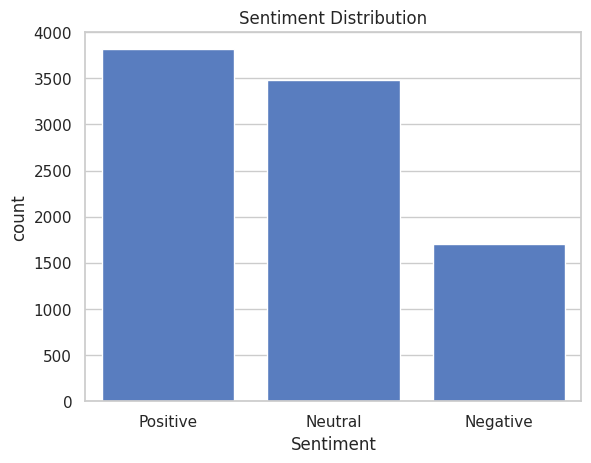

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="Sentiment")
plt.title("Sentiment Distribution")
plt.show()


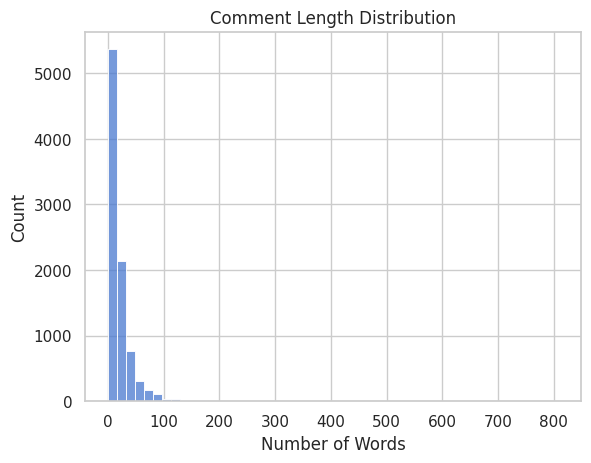

In [ ]:
df["comment_len"] = df["CommentText"].apply(lambda x: len(x.split()))

sns.histplot(df["comment_len"], bins=50)
plt.title("Comment Length Distribution")
plt.xlabel("Number of Words")
plt.show()


In [ ]:
print(df.isnull().sum())
print(df.dtypes)


VideoID           0
VideoTitle        0
CommentText       0
Sentiment         0
Likes             0
Replies           0
PublishedAt       0
CountryCode       0
CategoryID        0
SentimentLabel    0
comment_len       0
dtype: int64
VideoID                   object
VideoTitle                object
CommentText               object
Sentiment                 object
Likes                      int64
Replies                    int64
PublishedAt       datetime64[ns]
CountryCode               object
CategoryID                 int64
SentimentLabel             int64
comment_len                int64
dtype: object


                             **********NEW***************
---


---



---




In [ ]:
!pip install pandas numpy matplotlib seaborn
!pip install nltk scikit-learn
!pip install transformers datasets
!pip install torch torchvision torchaudio
!pip install jupyter notebook tqdm
!pip install python-dateutil pycountry


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 14.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system ==

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("df_small_balanced_9000.csv")  # Replace with your actual file path

# Show basic info
print(df.shape)
print(df.columns)
df.head()


(8999, 12)
Index(['CommentID', 'VideoID', 'VideoTitle', 'AuthorName', 'AuthorChannelID',
       'CommentText', 'Sentiment', 'Likes', 'Replies', 'PublishedAt',
       'CountryCode', 'CategoryID'],
      dtype='object')


,CommentID,VideoID,VideoTitle,AuthorName,AuthorChannelID,CommentText,Sentiment,Likes,Replies,PublishedAt,CountryCode,CategoryID
0,UgyL86eufYlpKeqzg414AaABAg,i5acg3Hvu6g,MySQL: SUBQUERIES,@alien3.0c,UCHGyJ5dffMKJGzsf2AHWW7Q,"Thanks, well explained",Positive,1,0,2023-06-04 16:34:09,CA,27
1,UgxxmQrbmehyvSO7Hld4AaABAg,46dZH7LDbf8,Mock Google Coding Interview with a Meta Intern,@IIRomoII,UCu9Zx3PoRNAJHAtRU1Gv0Ew,"11:11 I believe ""remove"" would be O(n) since i...",Neutral,0,0,2025-01-25 09:10:54,US,27
2,Ugwo_5loldrGAlQlpIR4AaABAg,rRTjPnVooxE,While loops in Python are easy ♾️,@Abzarad,UC6w8-4lDUsj3eitXbDXUZiQ,Thanks Bro,Positive,0,0,2024-12-04 21:09:14,CA,27
3,Ugww-OlBBpRA82Db0KR4AaABAg_aug,AR6eQCi_Me4,Lets build this project in Nextjs,AugmentedUser,AugmentedCID,Han G hum bhi a gae ha react or express se nex...,Neutral,0,0,2025-02-05 04:39:49,IN,27
4,UgxjKOuwEocVjxSDvbF4AaABAg,zb3Qk8SG5Ms,Node.js Crash Course Tutorial #1 - Introductio...,@hplat-vku,UCbVMkFfsVxvWE39BoZq8tsA,"thank brooooooooooo, \nAt first, i thought nod...",Positive,0,1,2024-06-28 17:55:28,GB,27


In [ ]:
# ✅ INSTALLS
!pip install transformers pandas scikit-learn textblob torch --quiet
!pip install pyspellchecker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 23.4 MB/s eta 0:00:00


In [ ]:
# ✅ IMPORTS
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn
from transformers import RobertaTokenizer, RobertaModel
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
import re
from spellchecker import SpellChecker
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
#  DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#  LOAD & PREPROCESS


spell = SpellChecker()

nltk.download('stopwords')

# Charger les données
df = pd.read_csv('/content/df_small_balanced_9000.csv')
df = df.dropna(subset=['CommentText', 'Sentiment', 'PublishedAt'])
df['PublishedAt'] = pd.to_datetime(df['PublishedAt'], errors='coerce')
df = df.dropna(subset=['PublishedAt'])
# Nettoyage des commentaires
def clean_comment(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = text.split()  # Simple split au lieu de word_tokenize
    tokens = [word for word in tokens if word not in stopwords.words('english')]
    return " ".join(tokens)




def sarcasm_features(text):
    exclam = text.count('!')
    question = text.count('?')
    all_caps_words = sum(1 for word in text.split() if word.isupper() and len(word) > 1)
    return [exclam, question, all_caps_words]

#  SENTIMENT ENCODING
sentiment_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df['label'] = df['Sentiment'].map(sentiment_map)

#  CLEAN + NUMERIC FEATURES
df['CommentText'] = df['CommentText'].apply(clean_comment)
df['CommentAgeDays'] = (pd.Timestamp.now() - df['PublishedAt']).dt.days
df['TextLength'] = df['CommentText'].apply(len)
df['WordCount'] = df['CommentText'].apply(lambda x: len(x.split()))
df['AvgWordLength'] = df['CommentText'].apply(lambda x: np.mean([len(w) for w in x.split()]) if x.strip() else 0)
df['Polarity'] = df['CommentText'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['Subjectivity'] = df['CommentText'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

# Sarcasm features
sarcasm_feats = df['CommentText'].apply(sarcasm_features)
df[['ExclamCount', 'QuestionCount', 'AllCapsWords']] = pd.DataFrame(sarcasm_feats.tolist(), index=df.index)

df.fillna(0, inplace=True)

NUMERIC_COLS = [
    'Likes', 'Replies', 'CommentAgeDays', 'TextLength', 'WordCount',
    'AvgWordLength', 'Polarity', 'Subjectivity',
    'ExclamCount', 'QuestionCount', 'AllCapsWords'
]
X_numeric = df[NUMERIC_COLS].values.astype(np.float32)

#  TEXT TOKENIZATION
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
tokens = tokenizer(list(df['CommentText']),
                   padding=True,
                   truncation=True,
                   max_length=128,
                   return_tensors="pt")

#  LABELS
labels = torch.tensor(df["label"].values)

#  SPLIT
train_idx, test_idx = train_test_split(range(len(df)), test_size=0.2, stratify=labels, random_state=42)

#  DATASET
class CommentDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels, numeric_feats):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = labels
        self.numeric_feats = torch.tensor(numeric_feats, dtype=torch.float)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels': self.labels[idx],
            'numeric_feats': self.numeric_feats[idx]
        }

train_dataset = CommentDataset(
    tokens['input_ids'][train_idx],
    tokens['attention_mask'][train_idx],
    labels[train_idx],
    X_numeric[train_idx]
)

test_dataset = CommentDataset(
    tokens['input_ids'][test_idx],
    tokens['attention_mask'][test_idx],
    labels[test_idx],
    X_numeric[test_idx]
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

#  MODEL
class RobertaMLPHybrid(nn.Module):
    def __init__(self, num_numeric_feats, num_classes):
        super(RobertaMLPHybrid, self).__init__()
        self.roberta = RobertaModel.from_pretrained('roberta-base')
        self.dropout = nn.Dropout(0.3)

        self.numeric_branch = nn.Sequential(
            nn.Linear(num_numeric_feats, 64),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
#MLP ici (nn)
        self.classifier = nn.Sequential(
            nn.Linear(self.roberta.config.hidden_size + 64, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, attention_mask, numeric_feats):
        transformer_out = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_token = transformer_out.last_hidden_state[:, 0, :]
        cls_token = self.dropout(cls_token)

        numeric_out = self.numeric_branch(numeric_feats)
        combined = torch.cat((cls_token, numeric_out), dim=1)

        return self.classifier(combined)

#  TRAINING SETUP
model = RobertaMLPHybrid(num_numeric_feats=11, num_classes=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

#  TRAINING LOOP
def train_model(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        numeric_feats = batch["numeric_feats"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, numeric_feats)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(dataloader)

#  EVAL FUNCTION
def evaluate_model(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            numeric_feats = batch["numeric_feats"].to(device)

            outputs = model(input_ids, attention_mask, numeric_feats)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

#  TRAIN LOOP
EPOCHS = 30
for epoch in range(EPOCHS):
    train_loss = train_model(model, train_loader, optimizer, criterion)
    acc = evaluate_model(model, test_loader)
    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Test Acc = {acc:.4f}")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1: Train Loss = 4.1437, Test Acc = 0.7061


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np
import torch.nn as nn # Import nn for CrossEntropyLoss
from tqdm import tqdm # Import tqdm


def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            numeric_feats = batch["numeric_feats"].to(device)  # Add numeric_feats

            outputs = model(input_ids, attention_mask, numeric_feats) # Pass numeric_feats
            loss = loss_fn(outputs, labels)

            total_loss += loss.item()

            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = np.argmax(probs, axis=1)

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    return total_loss / len(dataloader), accuracy, all_preds, all_labels, all_probs

from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

# Define loss_fn here
loss_fn = nn.CrossEntropyLoss()

val_loss, val_acc, y_pred, y_true, y_prob = evaluate(model, test_loader, loss_fn, device) # Change val_loader to test_loader

# Basic metrics
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
auc = roc_auc_score(y_true, y_prob, multi_class='ovo', average='weighted')

print(f"\nFinal Validation Metrics:")
print(f"Accuracy : {val_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Negative", "Neutral", "Positive"]))

Evaluating: 100%|██████████| 113/113 [00:11<00:00, 10.00it/s]


Final Validation Metrics:
Accuracy : 0.7550
Precision: 0.7645
Recall   : 0.7550
F1 Score : 0.7540
AUC      : 0.8604

Classification Report:
              precision    recall  f1-score   support

    Negative       0.72      0.55      0.62       340
     Neutral       0.67      0.82      0.74       697
    Positive       0.87      0.79      0.83       763

    accuracy                           0.76      1800
   macro avg       0.75      0.72      0.73      1800
weighted avg       0.76      0.76      0.75      1800



In [ ]:
from textblob import TextBlob
import numpy as np
import torch

def extract_numeric_features(text):
    words = text.split()
    polarity = TextBlob(text).sentiment.polarity
    subjectivity = TextBlob(text).sentiment.subjectivity
    exclam = text.count('!')
    question = text.count('?')
    all_caps_words = sum(1 for word in text.split() if word.isupper() and len(word) > 1)
    return np.array([
        0,  # Likes (unknown in inference, default to 0)
        0,  # Replies (unknown in inference)
        0,  # CommentAgeDays (optional: estimate or leave 0)
        len(text),                         # TextLength
        len(words),                        # WordCount
        np.mean([len(w) for w in words]) if words else 0,  # AvgWordLength
        polarity,
        subjectivity,
        exclam,
        question,
        all_caps_words
    ], dtype=np.float32)

def predict_sentiment(text, model, tokenizer, device):
    model.eval()

    # 1. Tokenize
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=128
    )
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    # 2. Extract numeric features
    numeric_feats = extract_numeric_features(text)
    numeric_feats = torch.tensor(numeric_feats).unsqueeze(0).to(device)

    # 3. Predict
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, numeric_feats=numeric_feats)
        probs = torch.softmax(outputs, dim=1)
        predicted_class = torch.argmax(probs, dim=1).item()

    return predicted_class, probs[0].cpu().numpy()

#  Example usage
text = "LOVEEE "
pred_label, probabilities = predict_sentiment(text, model, tokenizer, device)

label_map_inv = {0: 'negative', 1: 'neutral', 2: 'positive'}
print(f"Predicted: {label_map_inv[pred_label]}")
print(f"Probabilities: {probabilities}")

Predicted: positive
Probabilities: [6.7647375e-06 1.1405212e-06 9.9999201e-01]


In [ ]:
import re

def count_all_caps(text):
    return len(re.findall(r'\b[A-Z]{2,}\b', text))

# Replace 'comment' with 'CommentText' to access the correct column
df['All_Caps_Count'] = df['CommentText'].apply(count_all_caps)

<ipython-input-51-9fb7ee1ebcd4>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', order=['Negative', 'Neutral', 'Positive'], palette="Set2")
<ipython-input-51-9fb7ee1ebcd4>:6: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


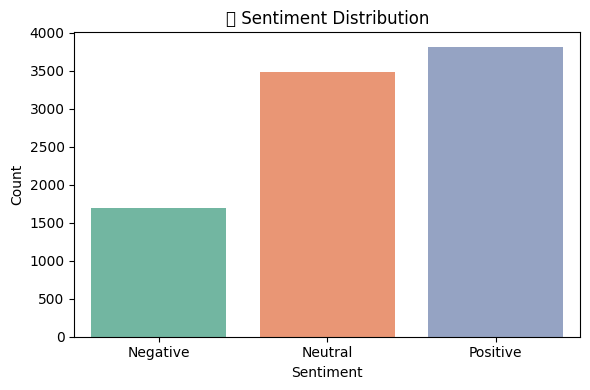

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Sentiment', order=['Negative', 'Neutral', 'Positive'], palette="Set2")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


<ipython-input-52-08c05106514b>:4: UserWarning: Glyph 128173 (\N{THOUGHT BALLOON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128173 (\N{THOUGHT BALLOON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


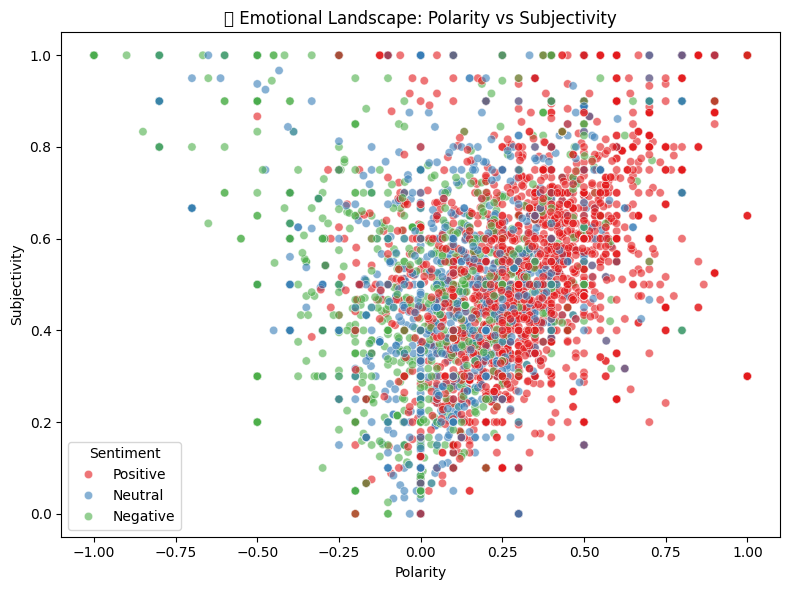

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Polarity', y='Subjectivity', hue='Sentiment', alpha=0.6, palette='Set1')
plt.title(" Emotional Landscape: Polarity vs Subjectivity")
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


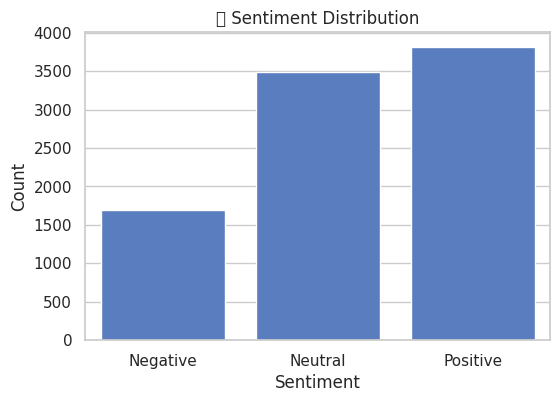

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128173 (\N{THOUGHT BALLOON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


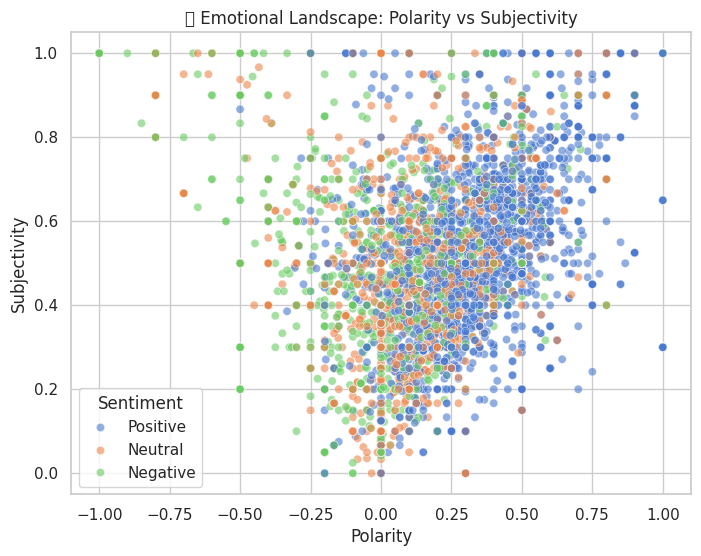

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


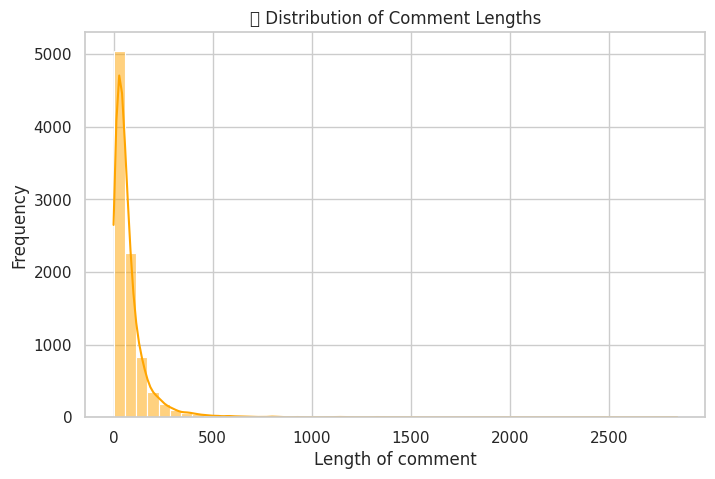

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


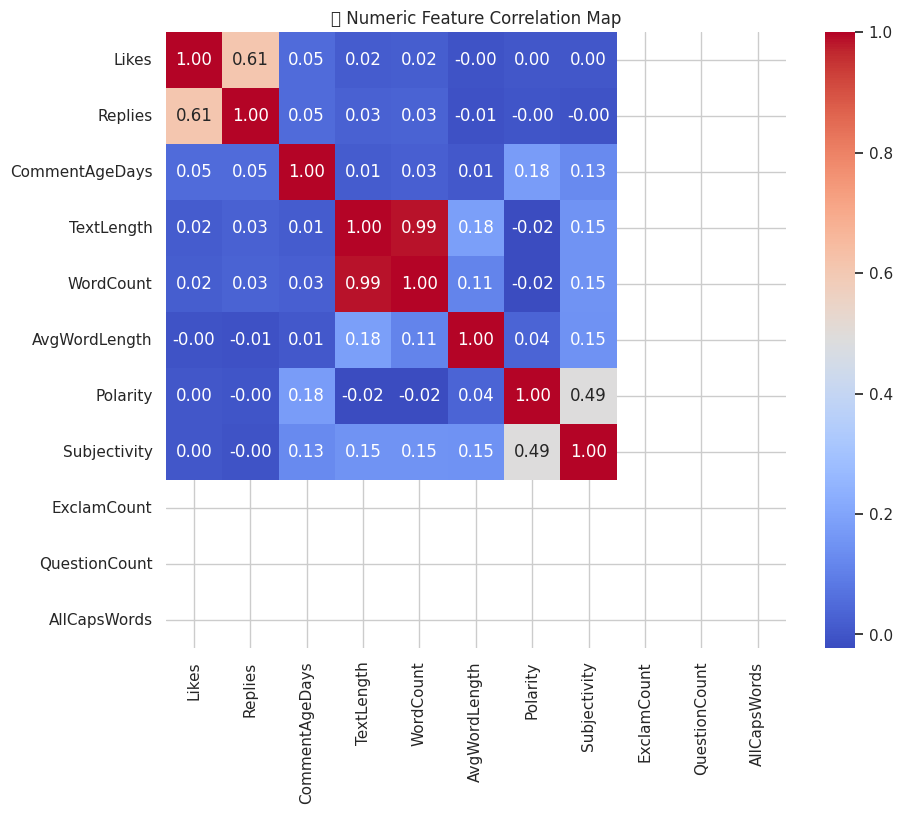

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


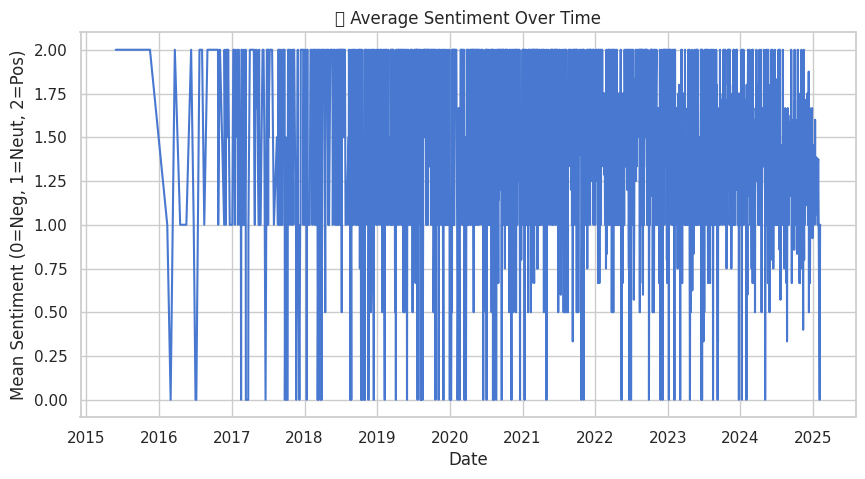

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set(style="whitegrid", palette="muted")

# 1. Sentiment Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Sentiment', order=['Negative', 'Neutral', 'Positive'])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# 2. Polarity vs Subjectivity
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Polarity', y='Subjectivity', hue='Sentiment', alpha=0.6)
plt.title(" Emotional Landscape: Polarity vs Subjectivity")
plt.show()

# 3. Comment Length Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['TextLength'], bins=50, kde=True, color='orange')
plt.title(" Distribution of Comment Lengths")
plt.xlabel("Length of comment")
plt.ylabel("Frequency")
plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[NUMERIC_COLS].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title(" Numeric Feature Correlation Map")
plt.show()

# 5. Average Sentiment Over Time
df['Date'] = df['PublishedAt'].dt.date
avg_sentiment_per_day = df.groupby('Date')['label'].mean()
plt.figure(figsize=(10, 5))
avg_sentiment_per_day.plot()
plt.title("Average Sentiment Over Time")
plt.ylabel("Mean Sentiment (0=Neg, 1=Neut, 2=Pos)")
plt.xlabel("Date")
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
df = pd.read_csv("df_small_balanced_9000.csv")
print(df['Sentiment'].value_counts())


Sentiment
Positive    3814
Neutral     3486
Negative    1699
Name: count, dtype: int64


In [ ]:
import pandas as pd

try:
    # Try reading with the default settings
    df = pd.read_csv('df_small_balanced_9000.csv')
except pd.errors.ParserError:
    # If the default fails, try adjusting parameters:
    df = pd.read_csv('df_small_balanced_9000.csv',
                     error_bad_lines=False,  # Skip bad lines
                     quoting=3)

# Separate by sentiment
positive_df = df[df['Sentiment'] == 'Positive']
neutral_df = df[df['Sentiment'] == 'Neutral']
negative_df = df[df['Sentiment'] == 'Negative']

# Target number of samples per class
target_count = len(negative_df)  # 1699

# Downsample positive and neutral to match negative
positive_downsampled = resample(positive_df,
                                replace=False,
                                n_samples=target_count,
                                random_state=42)

neutral_downsampled = resample(neutral_df,
                               replace=False,
                               n_samples=target_count,
                               random_state=42)

# Concatenate all
df_balanced = pd.concat([positive_downsampled, neutral_downsampled, negative_df])

# Shuffle the dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Check new distribution
print(df_balanced['Sentiment'].value_counts())



Sentiment
Positive    1699
Negative    1699
Neutral     1699
Name: count, dtype: int64
